# 03 - Denoising Autoencoder + Classifier

Run Notebook 01 first. This notebook trains the second deep-learning model of the project: a **denoising autoencoder (DAE)** whose encoder is reused as the feature extractor of a classifier.

**Why this model?** CICIDS2017 flow features are noisy, heavily correlated and heavy-tailed. A denoising autoencoder is trained to rebuild the clean features from a corrupted copy, so its encoder must learn a compact representation that keeps the stable structure of a flow and ignores small perturbations. A classifier trained on top of that representation should generalise better than a network trained on the raw features alone.

**Training happens in two stages:**
1. **Pretraining** - the autoencoder learns to reconstruct clean features from noisy input (no labels used).
2. **Fine-tuning** - a classification head is added on the latent vector. The whole network is trained with weighted cross-entropy plus a small reconstruction term that keeps the latent space informative.

The same frozen train / validation / test split and the same class weighting as the MLP are used, so the comparison is fair. The best checkpoint is selected with **validation macro-F1**; the test set is used only once at the end.

## Step 1 - Import the libraries

In [1]:
from pathlib import Path
import copy
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_fscore_support,
    roc_auc_score,
    silhouette_score,
)

## Step 2 - Set the file paths

In [2]:
PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROCESSED_FILE = PROJECT / 'data' / 'processed_data.npz'
MODELS_DIR = PROJECT / 'models'
MODEL_FILE = MODELS_DIR / 'autoencoder_classifier.pt'
RESULTS_DIR = PROJECT / 'results' / 'autoencoder'
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Step 3 - Set the random seed

In [3]:
RANDOM_STATE = 42


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_STATE)

## Step 4 - Select the training device

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Training device:', device)

Training device: cpu


## Step 5 - Load the processed dataset

In [5]:
if not PROCESSED_FILE.exists():
    raise FileNotFoundError('Run Notebook 01 before training the model.')

processed_data = np.load(PROCESSED_FILE)
if 'X_val' not in processed_data.files:
    raise ValueError('The processed file has no validation set. Re-run Notebook 01.')

X_train = processed_data['X_train']
X_val = processed_data['X_val']
X_test = processed_data['X_test']
y_train = processed_data['y_train']
y_val = processed_data['y_val']
y_test = processed_data['y_test']

## Step 6 - Load the class names

In [6]:
label_encoder = joblib.load(MODELS_DIR / 'label_encoder.joblib')
class_names = list(label_encoder.classes_)
number_of_classes = len(class_names)
BENIGN_INDEX = class_names.index('BENIGN')
print('Classes:', class_names)

Classes: ['BENIGN', 'Botnet', 'Brute Force', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'PortScan', 'Web Attack']


## Step 7 - Check the dataset shapes and class distribution

In [7]:
print('X_train:', X_train.shape, ' X_val:', X_val.shape, ' X_test:', X_test.shape)

distribution = pd.DataFrame({
    'train': np.bincount(y_train, minlength=number_of_classes),
    'validation': np.bincount(y_val, minlength=number_of_classes),
    'test': np.bincount(y_test, minlength=number_of_classes),
}, index=class_names)
display(distribution)

X_train: (1765652, 69)  X_val: (252237, 69)  X_test: (504473, 69)


,train,validation,test
BENIGN,1467538,209649,419297
Botnet,1367,195,391
Brute Force,6407,915,1830
DDoS,89611,12802,25603
DoS,135623,19375,38750
Heartbleed,8,1,2
Infiltration,25,4,7
PortScan,63573,9082,18164
Web Attack,1500,214,429


## Step 8 - Set the training configuration

All hyperparameters are kept in one dictionary so the exact configuration can be saved with the results.

| Hyperparameter | Value | Reason |
|---|---|---|
| Encoder layers | 128 -> 64 -> latent | Gradually compresses the 69 features, the same width scale as the MLP |
| Latent size | 32 | About half of the input features; tuned in Step 13 |
| Noise level (std) | 0.10 | Gaussian noise on standardised features; tuned in Step 13 |
| Reconstruction loss | Huber | Flow features are heavy-tailed even after scaling; Huber stops a few extreme flows from dominating the loss |
| Classifier layers | 64 -> 32 -> classes | Small head, because the latent vector is already compact |
| Encoder learning rate | 1e-4 | Lower than the head so fine-tuning does not destroy the pretrained representation |
| Reconstruction weight | 0.10 | Keeps the latent space informative during fine-tuning without overpowering the classification loss |
| Early stopping | 4 epochs on validation macro-F1 | Stops when the model stops improving on unseen data |

In [8]:
CONFIG = {
    'random_state': RANDOM_STATE,
    'encoder_layers': [128, 64],
    'latent_size': 32,
    'classifier_layers': [64, 32],
    'noise_std': 0.10,
    'dropout': 0.20,
    'batch_size': 1024,
    'pretrain_epochs': 10,
    'pretrain_learning_rate': 1e-3,
    'finetune_epochs': 20,
    'encoder_learning_rate': 1e-4,
    'classifier_learning_rate': 1e-3,
    'weight_decay': 1e-5,
    'reconstruction_weight': 0.10,
    'early_stopping_patience': 4,
}
CONFIG

{'random_state': 42,
 'encoder_layers': [128, 64],
 'latent_size': 32,
 'classifier_layers': [64, 32],
 'noise_std': 0.1,
 'dropout': 0.2,
 'batch_size': 1024,
 'pretrain_epochs': 10,
 'pretrain_learning_rate': 0.001,
 'finetune_epochs': 20,
 'encoder_learning_rate': 0.0001,
 'classifier_learning_rate': 0.001,
 'weight_decay': 1e-05,
 'reconstruction_weight': 0.1,
 'early_stopping_patience': 4}

## Step 9 - Create the data loaders

In [9]:
def make_loader(features, labels, batch_size, shuffle):
    dataset = TensorDataset(torch.from_numpy(features), torch.from_numpy(labels))
    # drop_last on the training loader avoids a final batch of size 1, which BatchNorm cannot handle.
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)


train_loader = make_loader(X_train, y_train, CONFIG['batch_size'], shuffle=True)
val_loader = make_loader(X_val, y_val, CONFIG['batch_size'], shuffle=False)

## Step 10 - Calculate the class weights

The same balanced class weights as the MLP are used, so any difference between the two models comes from the architecture and not from the imbalance handling.

In [10]:
class_counts = np.bincount(y_train, minlength=number_of_classes)
weight_values = len(y_train) / (number_of_classes * class_counts)
class_weights = torch.tensor(weight_values, dtype=torch.float32, device=device)
print(pd.Series(weight_values, index=class_names).round(2))

BENIGN              0.13
Botnet            143.51
Brute Force        30.62
DDoS                2.19
DoS                 1.45
Heartbleed      24522.94
Infiltration     7847.34
PortScan            3.09
Web Attack        130.79
dtype: float64


## Step 11 - Define the denoising autoencoder and the classifier

- **DenoisingAutoencoder** - adds Gaussian noise to the input (only in training mode), encodes it to a latent vector and decodes it back to the clean features.
- **AutoencoderClassifier** - reuses the pretrained encoder and puts a small classification head on the latent vector. It also returns the reconstruction so the reconstruction term can be kept during fine-tuning.

In [11]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_size, encoder_layers, latent_size, noise_std):
        super().__init__()
        self.noise_std = noise_std

        encoder = []
        previous_size = input_size
        for width in encoder_layers:
            encoder += [nn.Linear(previous_size, width), nn.BatchNorm1d(width), nn.ReLU()]
            previous_size = width
        encoder.append(nn.Linear(previous_size, latent_size))
        self.encoder = nn.Sequential(*encoder)

        decoder = []
        previous_size = latent_size
        for width in reversed(encoder_layers):
            decoder += [nn.Linear(previous_size, width), nn.ReLU()]
            previous_size = width
        decoder.append(nn.Linear(previous_size, input_size))
        self.decoder = nn.Sequential(*decoder)

    def corrupt(self, features):
        # Noise is only added while training; evaluation always uses the clean input.
        if self.training and self.noise_std > 0:
            return features + self.noise_std * torch.randn_like(features)
        return features

    def forward(self, features):
        latent = self.encoder(self.corrupt(features))
        return self.decoder(latent), latent


class AutoencoderClassifier(nn.Module):
    def __init__(self, autoencoder, latent_size, classifier_layers, output_size, dropout):
        super().__init__()
        self.autoencoder = autoencoder

        layers = []
        previous_size = latent_size
        for width in classifier_layers:
            layers += [nn.Linear(previous_size, width), nn.BatchNorm1d(width), nn.ReLU(), nn.Dropout(dropout)]
            previous_size = width
        layers.append(nn.Linear(previous_size, output_size))
        self.classifier = nn.Sequential(*layers)

    def forward(self, features):
        reconstruction, latent = self.autoencoder(features)
        return self.classifier(latent), reconstruction, latent


def build_model(config):
    autoencoder = DenoisingAutoencoder(
        X_train.shape[1], config['encoder_layers'], config['latent_size'], config['noise_std'],
    )
    model = AutoencoderClassifier(
        autoencoder, config['latent_size'], config['classifier_layers'], number_of_classes, config['dropout'],
    )
    return model.to(device)


build_model(CONFIG)

AutoencoderClassifier(
  (autoencoder): DenoisingAutoencoder(
    (encoder): Sequential(
      (0): Linear(in_features=69, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=64, out_features=32, bias=True)
    )
    (decoder): Sequential(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=69, bias=True)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dr

## Step 12 - Define the training and prediction functions

- `pretrain_autoencoder` - stage 1, reconstruction only. Keeps the epoch with the lowest validation reconstruction loss.
- `finetune_classifier` - stage 2, weighted cross-entropy + reconstruction term. Keeps the epoch with the highest validation macro-F1 and stops early when it no longer improves.
- `predict` - returns class probabilities, per-flow reconstruction error and latent vectors.

In [12]:
reconstruction_loss_function = nn.HuberLoss()


def evaluate_reconstruction(autoencoder, loader):
    autoencoder.eval()
    total_loss = 0.0
    with torch.no_grad():
        for features, _ in loader:
            features = features.to(device)
            reconstruction, _ = autoencoder(features)
            total_loss += reconstruction_loss_function(reconstruction, features).item() * len(features)
    return total_loss / len(loader.dataset)


def pretrain_autoencoder(autoencoder, train_loader, val_loader, config):
    optimizer = torch.optim.Adam(
        autoencoder.parameters(), lr=config['pretrain_learning_rate'], weight_decay=config['weight_decay'],
    )
    history = []
    best_loss, best_state = float('inf'), None

    for epoch in range(1, config['pretrain_epochs'] + 1):
        autoencoder.train()
        total_loss = 0.0
        for features, _ in train_loader:
            features = features.to(device)
            optimizer.zero_grad()
            reconstruction, _ = autoencoder(features)
            # The target is the clean input, not the noisy one: this is what makes it a denoising autoencoder.
            loss = reconstruction_loss_function(reconstruction, features)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(features)

        train_loss = total_loss / (len(train_loader) * train_loader.batch_size)
        val_loss = evaluate_reconstruction(autoencoder, val_loader)
        history.append({'epoch': epoch, 'train_reconstruction_loss': train_loss, 'val_reconstruction_loss': val_loss})
        print(f'Pretrain epoch {epoch:02d} - train: {train_loss:.4f}  val: {val_loss:.4f}')

        if val_loss < best_loss:
            best_loss, best_state = val_loss, copy.deepcopy(autoencoder.state_dict())

    autoencoder.load_state_dict(best_state)
    return pd.DataFrame(history)


def evaluate_classifier(model, loader, loss_function):
    model.eval()
    total_loss = 0.0
    predictions, targets = [], []
    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            logits, _, _ = model(features)
            total_loss += loss_function(logits, labels).item() * len(labels)
            predictions.append(logits.argmax(dim=1).cpu().numpy())
            targets.append(labels.cpu().numpy())
    predictions, targets = np.concatenate(predictions), np.concatenate(targets)
    return total_loss / len(loader.dataset), f1_score(targets, predictions, average='macro')


def finetune_classifier(model, train_loader, val_loader, class_weights, config):
    classification_loss_function = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam([
        {'params': model.autoencoder.parameters(), 'lr': config['encoder_learning_rate']},
        {'params': model.classifier.parameters(), 'lr': config['classifier_learning_rate']},
    ], weight_decay=config['weight_decay'])

    history = []
    best_f1, best_epoch, best_state = -1.0, 0, None
    epochs_without_improvement = 0

    for epoch in range(1, config['finetune_epochs'] + 1):
        model.train()
        total_loss = 0.0
        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad()
            logits, reconstruction, _ = model(features)
            loss = (
                classification_loss_function(logits, labels)
                + config['reconstruction_weight'] * reconstruction_loss_function(reconstruction, features)
            )
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(labels)

        train_loss = total_loss / (len(train_loader) * train_loader.batch_size)
        val_loss, val_f1 = evaluate_classifier(model, val_loader, classification_loss_function)
        history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'val_macro_f1': val_f1})
        print(f'Fine-tune epoch {epoch:02d} - train loss: {train_loss:.4f}  val loss: {val_loss:.4f}  val macro-F1: {val_f1:.4f}')

        if val_f1 > best_f1:
            best_f1, best_epoch, best_state = val_f1, epoch, copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= config['early_stopping_patience']:
                print(f'Early stopping at epoch {epoch}.')
                break

    model.load_state_dict(best_state)
    return pd.DataFrame(history), best_epoch, best_f1


def predict(model, features, batch_size=4096, keep_latent=True):
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(features)), batch_size=batch_size)
    probabilities, errors, latents = [], [], []
    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)
            logits, reconstruction, latent = model(batch)
            probabilities.append(torch.softmax(logits, dim=1).cpu().numpy())
            errors.append(((reconstruction - batch) ** 2).mean(dim=1).cpu().numpy())
            if keep_latent:
                latents.append(latent.cpu().numpy())
    latents = np.concatenate(latents) if keep_latent else None
    return np.concatenate(probabilities), np.concatenate(errors), latents


def train_model(config, train_loader, val_loader):
    set_seed(config['random_state'])
    model = build_model(config)
    start = time.perf_counter()
    pretrain_history = pretrain_autoencoder(model.autoencoder, train_loader, val_loader, config)
    pretrain_seconds = time.perf_counter() - start
    start = time.perf_counter()
    finetune_history, best_epoch, best_f1 = finetune_classifier(model, train_loader, val_loader, class_weights, config)
    finetune_seconds = time.perf_counter() - start
    return model, pretrain_history, finetune_history, best_epoch, best_f1, pretrain_seconds, finetune_seconds

## Step 13 - Tune the noise level and latent size (validation set only)

Every configuration is trained on the same stratified 300,000-row subset of the training data with a shortened schedule, then scored on the full validation set. The test set is **not** used.

The run with `noise_std = 0.0` is an ordinary (non-denoising) autoencoder. Comparing it with the noisy runs answers the question *"does denoising actually help?"*.

Set `RUN_TUNING = False` to skip this step and keep the default configuration.

In [13]:
RUN_TUNING = True
TUNING_ROWS = 300_000
TUNING_GRID = [
    {'noise_std': 0.00, 'latent_size': 32},
    {'noise_std': 0.05, 'latent_size': 32},
    {'noise_std': 0.10, 'latent_size': 32},
    {'noise_std': 0.20, 'latent_size': 32},
    {'noise_std': 0.10, 'latent_size': 16},
    {'noise_std': 0.10, 'latent_size': 64},
]

if RUN_TUNING:
    tuning_index, _ = train_test_split(
        np.arange(len(y_train)),
        train_size=min(TUNING_ROWS, len(y_train) - number_of_classes),
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
    tuning_loader = make_loader(X_train[tuning_index], y_train[tuning_index], CONFIG['batch_size'], shuffle=True)

    tuning_results = []
    for settings in TUNING_GRID:
        trial_config = {**CONFIG, **settings, 'pretrain_epochs': 3, 'finetune_epochs': 6, 'early_stopping_patience': 2}
        print(f'\n=== noise_std={settings["noise_std"]}  latent_size={settings["latent_size"]} ===')
        _, _, _, trial_epoch, trial_f1, pre_s, fine_s = train_model(trial_config, tuning_loader, val_loader)
        tuning_results.append({**settings, 'best_epoch': trial_epoch, 'val_macro_f1': trial_f1, 'train_seconds': pre_s + fine_s})

    tuning_table = pd.DataFrame(tuning_results).sort_values('val_macro_f1', ascending=False)
    tuning_table.to_csv(RESULTS_DIR / 'tuning_results.csv', index=False)
    display(tuning_table)

    best_settings = tuning_table.iloc[0]
    CONFIG['noise_std'] = float(best_settings['noise_std'])
    CONFIG['latent_size'] = int(best_settings['latent_size'])

print('Final configuration:', CONFIG)


=== noise_std=0.0  latent_size=32 ===


Pretrain epoch 01 - train: 0.0516  val: 0.0234


Pretrain epoch 02 - train: 0.0195  val: 0.0127


Pretrain epoch 03 - train: 0.0116  val: 0.0078


Fine-tune epoch 01 - train loss: 0.9551  val loss: 0.4651  val macro-F1: 0.3518


...

Fine-tune epoch 04 - train loss: 0.3422  val loss: 0.2298  val macro-F1: 0.4127


Fine-tune epoch 05 - train loss: 0.3112  val loss: 0.2073  val macro-F1: 0.4112


Fine-tune epoch 06 - train loss: 0.2711  val loss: 0.1806  val macro-F1: 0.4150


,noise_std,latent_size,best_epoch,val_macro_f1,train_seconds
0,0.00,32,6,0.438573,114.592213
4,0.10,16,6,0.419834,200.479048
1,0.05,32,6,0.418702,121.747755
2,0.10,32,5,0.416742,105.608907
5,0.10,64,6,0.414977,122.336835
3,0.20,32,5,0.408042,129.327221


Final configuration: {'random_state': 42, 'encoder_layers': [128, 64], 'latent_size': 32, 'classifier_layers': [64, 32], 'noise_std': 0.0, 'dropout': 0.2, 'batch_size': 1024, 'pretrain_epochs': 10, 'pretrain_learning_rate': 0.001, 'finetune_epochs': 20, 'encoder_learning_rate': 0.0001, 'classifier_learning_rate': 0.001, 'weight_decay': 1e-05, 'reconstruction_weight': 0.1, 'early_stopping_patience': 4}


## Step 14 - Train the final model on the full training set

In [14]:
(
    model,
    pretrain_history,
    finetune_history,
    best_epoch,
    best_val_f1,
    pretrain_seconds,
    finetune_seconds,
) = train_model(CONFIG, train_loader, val_loader)

print(f'\nBest epoch: {best_epoch}  validation macro-F1: {best_val_f1:.4f}')
print(f'Training time: pretrain {pretrain_seconds:.1f}s + fine-tune {finetune_seconds:.1f}s')

Pretrain epoch 01 - train: 0.0169  val: 0.0053


Pretrain epoch 02 - train: 0.0052  val: 0.0034


Pretrain epoch 03 - train: 0.0041  val: 0.0030


Pretrain epoch 04 - train: 0.0037  val: 0.0026


Pretrain epoch 05 - train: 0.0034  val: 0.0044


...

Fine-tune epoch 15 - train loss: 0.0963  val loss: 0.0623  val macro-F1: 0.6295


Fine-tune epoch 16 - train loss: 0.0923  val loss: 0.0674  val macro-F1: 0.5425


Fine-tune epoch 17 - train loss: 0.0867  val loss: 0.0610  val macro-F1: 0.6293


Fine-tune epoch 18 - train loss: 0.0864  val loss: 0.0647  val macro-F1: 0.5300


Fine-tune epoch 19 - train loss: 0.0880  val loss: 0.0615  val macro-F1: 0.5882
Early stopping at epoch 19.

Best epoch: 15  validation macro-F1: 0.6295
Training time: pretrain 584.4s + fine-tune 1108.2s


## Step 15 - Display the learning curves

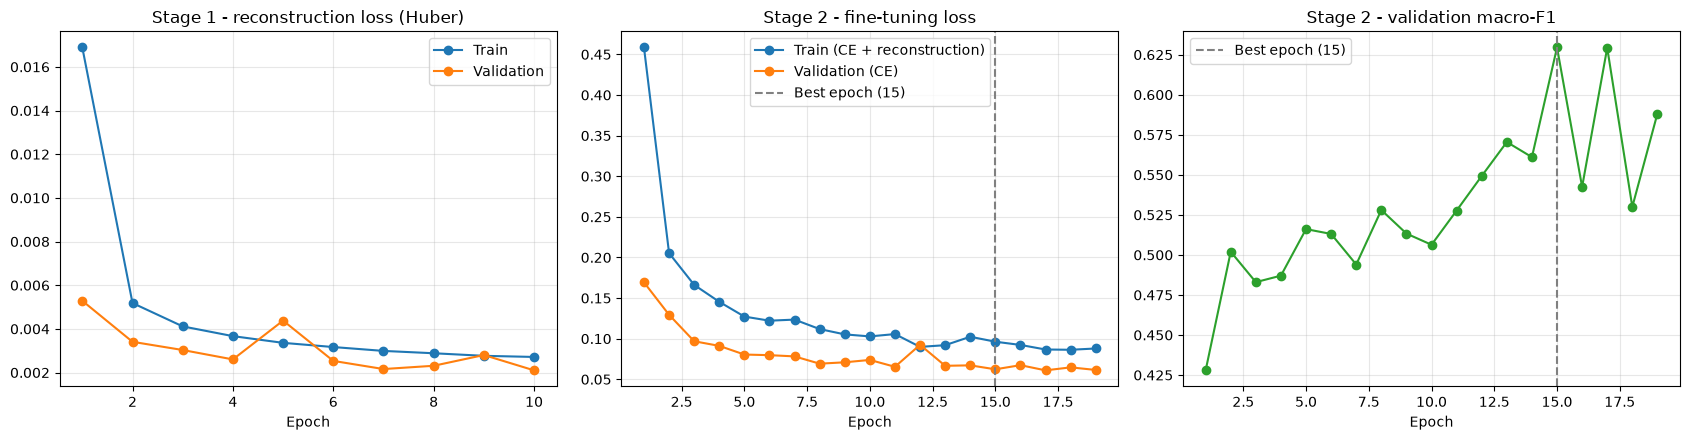

In [15]:
figure, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(pretrain_history['epoch'], pretrain_history['train_reconstruction_loss'], marker='o', label='Train')
axes[0].plot(pretrain_history['epoch'], pretrain_history['val_reconstruction_loss'], marker='o', label='Validation')
axes[0].set_title('Stage 1 - reconstruction loss (Huber)')

axes[1].plot(finetune_history['epoch'], finetune_history['train_loss'], marker='o', label='Train (CE + reconstruction)')
axes[1].plot(finetune_history['epoch'], finetune_history['val_loss'], marker='o', label='Validation (CE)')
axes[1].set_title('Stage 2 - fine-tuning loss')

axes[2].plot(finetune_history['epoch'], finetune_history['val_macro_f1'], marker='o', color='tab:green')
axes[2].set_title('Stage 2 - validation macro-F1')

for axis in axes:
    axis.set_xlabel('Epoch')
    axis.grid(alpha=0.3)
for axis in axes[1:]:
    axis.axvline(best_epoch, color='grey', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[0].legend()
axes[1].legend()
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'learning_curves.png', dpi=150)
plt.show()

## Step 16 - Save the model, configuration and training history

In [16]:
torch.save(model.state_dict(), MODEL_FILE)
pretrain_history.to_csv(RESULTS_DIR / 'pretrain_history.csv', index=False)
finetune_history.to_csv(RESULTS_DIR / 'finetune_history.csv', index=False)
with open(RESULTS_DIR / 'config.json', 'w') as file:
    json.dump(CONFIG, file, indent=2)
print('Model saved:', MODEL_FILE)

Model saved: C:\Users\Matheesha\Desktop\4th year\Y4 S1\Deep Learning\Assignment\SE4050-DL\models\autoencoder_classifier.pt


## Step 17 - Make predictions on the training, validation and test sets

All model decisions are now final. From this step onward the test set is used for evaluation only. Inference time on the test set is measured here.

In [17]:
train_probabilities, _, _ = predict(model, X_train, keep_latent=False)
val_probabilities, _, _ = predict(model, X_val, keep_latent=False)

if device.type == 'cuda':
    torch.cuda.synchronize()
start = time.perf_counter()
test_probabilities, test_reconstruction_error, test_latent = predict(model, X_test)
if device.type == 'cuda':
    torch.cuda.synchronize()
inference_seconds = time.perf_counter() - start

train_predictions = train_probabilities.argmax(axis=1)
val_predictions = val_probabilities.argmax(axis=1)
test_predictions = test_probabilities.argmax(axis=1)
print(f'Test inference: {inference_seconds:.2f}s for {len(X_test):,} flows '
      f'({1000 * inference_seconds / len(X_test):.4f} ms per flow)')

Test inference: 4.07s for 504,473 flows (0.0081 ms per flow)


## Step 18 - Compare training, validation and test performance (generalisation)

A large gap between training and validation/test macro-F1 would indicate overfitting.

In [18]:
generalisation = pd.DataFrame([
    {
        'split': name,
        'accuracy': accuracy_score(targets, predictions),
        'balanced_accuracy': balanced_accuracy_score(targets, predictions),
        'macro_f1': f1_score(targets, predictions, average='macro'),
        'weighted_f1': f1_score(targets, predictions, average='weighted'),
    }
    for name, targets, predictions in [
        ('train', y_train, train_predictions),
        ('validation', y_val, val_predictions),
        ('test', y_test, test_predictions),
    ]
]).set_index('split')
generalisation.to_csv(RESULTS_DIR / 'generalisation.csv')
display(generalisation.round(4))

,accuracy,balanced_accuracy,macro_f1,weighted_f1
split,,,,
train,0.9286,0.9530,0.5965,0.9436
validation,0.9288,0.9838,0.6295,0.9437
test,0.9282,0.9685,0.6034,0.9434


## Step 19 - Calculate the multiclass (attack family) metrics on the test set

In [19]:
all_labels = np.arange(number_of_classes)
print(classification_report(
    y_test, test_predictions, labels=all_labels, target_names=class_names, digits=4, zero_division=0,
))

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, test_predictions, labels=all_labels, zero_division=0,
)
per_class = pd.DataFrame(
    {'precision': precision, 'recall': recall, 'f1': f1, 'support': support}, index=class_names,
)
per_class.to_csv(RESULTS_DIR / 'per_class_metrics.csv')

multiclass_metrics = {
    'accuracy': accuracy_score(y_test, test_predictions),
    'balanced_accuracy': balanced_accuracy_score(y_test, test_predictions),
    'macro_precision': precision_recall_fscore_support(y_test, test_predictions, average='macro', zero_division=0)[0],
    'macro_recall': precision_recall_fscore_support(y_test, test_predictions, average='macro', zero_division=0)[1],
    'macro_f1': f1_score(y_test, test_predictions, average='macro'),
    'weighted_f1': f1_score(y_test, test_predictions, average='weighted'),
}
pd.Series(multiclass_metrics).round(4)

              precision    recall  f1-score   support

      BENIGN     0.9997    0.9149    0.9554    419297
      Botnet     0.0322    1.0000    0.0624       391
 Brute Force     0.5557    0.9678    0.7060      1830
        DDoS     0.8707    0.9991    0.9305     25603
         DoS     0.8220    0.9898    0.8981     38750
  Heartbleed     0.6667    1.0000    0.8000         2
Infiltration     0.0287    0.8571    0.0556         7
    PortScan     0.7266    0.9973    0.8407     18164
  Web Attack     0.1003    0.9907    0.1822       429

    accuracy                         0.9282    504473
   macro avg     0.5336    0.9685    0.6034    504473
weighted avg     0.9665    0.9282    0.9434    504473



accuracy             0.9282
balanced_accuracy    0.9685
macro_precision      0.5336
macro_recall         0.9685
macro_f1             0.6034
weighted_f1          0.9434
dtype: float64

## Step 20 - Display the confusion matrices

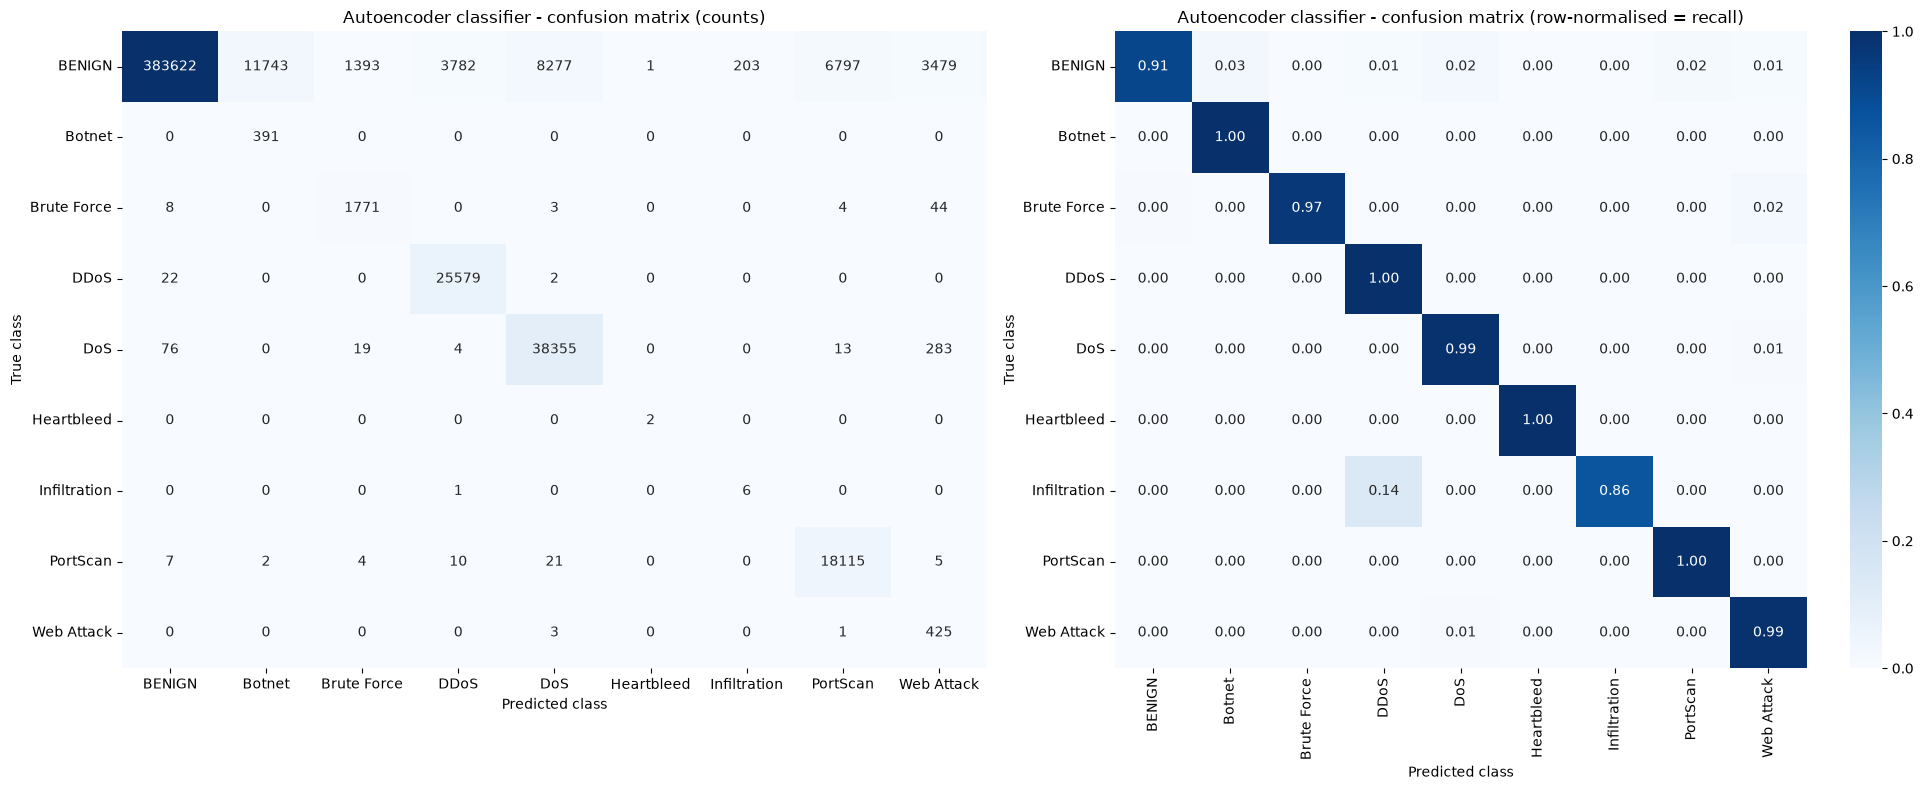

In [20]:
matrix = confusion_matrix(y_test, test_predictions, labels=all_labels)
row_normalised = matrix / matrix.sum(axis=1, keepdims=True)

figure, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(matrix, cmap='Blues', annot=True, fmt='d', cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Autoencoder classifier - confusion matrix (counts)')
sns.heatmap(row_normalised, cmap='Blues', annot=True, fmt='.2f', vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Autoencoder classifier - confusion matrix (row-normalised = recall)')
for axis in axes:
    axis.set_xlabel('Predicted class')
    axis.set_ylabel('True class')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## Step 21 - Calculate the binary intrusion-detection metrics

Every prediction that is not BENIGN is mapped to ATTACK. The attack score used for ROC-AUC and PR-AUC is `1 - P(BENIGN)`.

In [21]:
y_test_binary = (y_test != BENIGN_INDEX).astype(int)
test_predictions_binary = (test_predictions != BENIGN_INDEX).astype(int)
attack_score = 1 - test_probabilities[:, BENIGN_INDEX]

true_negative, false_positive, false_negative, true_positive = confusion_matrix(
    y_test_binary, test_predictions_binary, labels=[0, 1],
).ravel()
binary_precision, binary_recall, binary_f1, _ = precision_recall_fscore_support(
    y_test_binary, test_predictions_binary, average='binary', zero_division=0,
)
binary_metrics = {
    'precision': binary_precision,
    'recall_detection_rate': binary_recall,
    'f1': binary_f1,
    'roc_auc': roc_auc_score(y_test_binary, attack_score),
    'pr_auc': average_precision_score(y_test_binary, attack_score),
    'false_positive_rate': false_positive / (false_positive + true_negative),
    'mcc': matthews_corrcoef(y_test_binary, test_predictions_binary),
    'true_negative': int(true_negative),
    'false_positive': int(false_positive),
    'false_negative': int(false_negative),
    'true_positive': int(true_positive),
}
pd.Series(binary_metrics).round(4)

precision                     0.7045
recall_detection_rate         0.9987
f1                            0.8262
roc_auc                       0.9955
pr_auc                        0.9794
false_positive_rate           0.0851
mcc                           0.8021
true_negative            383622.0000
false_positive            35675.0000
false_negative              113.0000
true_positive             85063.0000
dtype: float64

## Step 22 - Measure the model complexity and efficiency

In [22]:
parameter_count = sum(parameter.numel() for parameter in model.parameters())
encoder_parameters = sum(parameter.numel() for parameter in model.autoencoder.encoder.parameters())
decoder_parameters = sum(parameter.numel() for parameter in model.autoencoder.decoder.parameters())
classifier_parameters = sum(parameter.numel() for parameter in model.classifier.parameters())

efficiency_metrics = {
    'total_parameters': parameter_count,
    'encoder_parameters': encoder_parameters,
    'decoder_parameters': decoder_parameters,
    'classifier_parameters': classifier_parameters,
    'inference_parameters': encoder_parameters + classifier_parameters,
    'model_file_mb': MODEL_FILE.stat().st_size / 1024 ** 2,
    'pretrain_seconds': pretrain_seconds,
    'finetune_seconds': finetune_seconds,
    'total_training_seconds': pretrain_seconds + finetune_seconds,
    'best_epoch': best_epoch,
    'epochs_run': int(finetune_history['epoch'].max()),
    'test_inference_seconds': inference_seconds,
    'inference_ms_per_1000_flows': 1000 * 1000 * inference_seconds / len(X_test),
    'device': str(device),
}
if device.type == 'cuda':
    efficiency_metrics['peak_gpu_memory_mb'] = torch.cuda.max_memory_allocated() / 1024 ** 2
pd.Series(efficiency_metrics)

total_parameters                     43694
encoder_parameters                   19680
decoder_parameters                   19333
classifier_parameters                 4681
inference_parameters                 24361
model_file_mb                      0.18189
pretrain_seconds                584.384615
finetune_seconds                1108.22805
total_training_seconds         1692.612665
best_epoch                              15
epochs_run                              19
test_inference_seconds            4.067853
inference_ms_per_1000_flows       8.063569
device                                 cpu
dtype: object

## Step 23 - Save all metrics and the test predictions

`metrics.json` and `test_predictions.npz` use the same format for every model, so the group comparison and the dashboard read saved results instead of re-calculating them.

In [23]:
def to_builtin(values):
    return {key: (value.item() if hasattr(value, 'item') else value) for key, value in values.items()}


all_metrics = {
    'model': 'Denoising Autoencoder + Classifier',
    'config': CONFIG,
    'best_validation_macro_f1': best_val_f1,
    'multiclass': to_builtin(multiclass_metrics),
    'binary': to_builtin(binary_metrics),
    'efficiency': to_builtin(efficiency_metrics),
}
with open(RESULTS_DIR / 'metrics.json', 'w') as file:
    json.dump(all_metrics, file, indent=2)

np.savez_compressed(
    RESULTS_DIR / 'test_predictions.npz',
    y_true=y_test,
    y_pred=test_predictions,
    probabilities=test_probabilities.astype(np.float32),
    class_names=np.array(class_names),
)
print('Saved metrics and predictions in', RESULTS_DIR)

Saved metrics and predictions in C:\Users\Matheesha\Desktop\4th year\Y4 S1\Deep Learning\Assignment\SE4050-DL\results\autoencoder


## Step 24 - Analyse the reconstruction error per class

The autoencoder never sees labels during pretraining. If attacks have a higher reconstruction error than benign traffic, the representation has captured what "normal" traffic looks like. The ROC-AUC of the reconstruction error alone shows how well it would work as an unsupervised anomaly detector.

,count,mean,std,min,50%,95%,max
class,,,,,,,
BENIGN,419297.0,0.3384,41.9186,0.0000,0.0008,0.0231,11256.6123
Botnet,391.0,0.0533,0.4566,0.0005,0.0029,0.0179,5.4392
Brute Force,1830.0,0.0053,0.0560,0.0004,0.0030,0.0041,1.5410
DDoS,25603.0,0.0068,0.0214,0.0004,0.0027,0.0252,2.9357
DoS,38750.0,0.0130,0.0439,0.0003,0.0045,0.0337,1.5464
Heartbleed,2.0,1.5750,0.0284,1.5549,1.5750,1.5930,1.5950
Infiltration,7.0,350.9380,600.6600,0.0005,47.8853,1316.4861,1621.2836
PortScan,18164.0,0.0057,0.0533,0.0001,0.0008,0.0041,0.9251
Web Attack,429.0,0.0077,0.0424,0.0003,0.0011,0.0026,0.2830


ROC-AUC of reconstruction error alone (BENIGN vs ATTACK): 0.6985


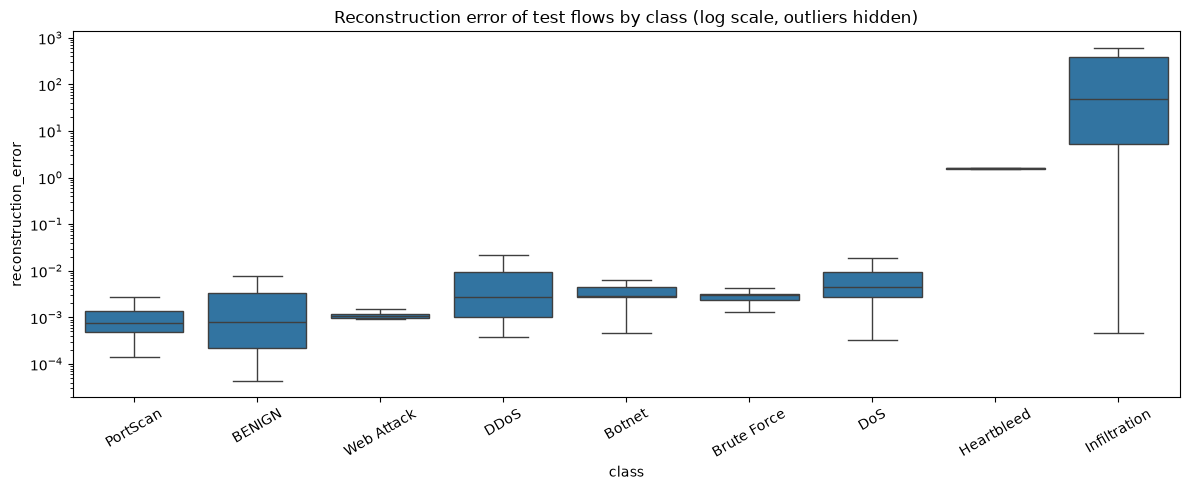

In [24]:
error_table = pd.DataFrame({'class': np.array(class_names)[y_test], 'reconstruction_error': test_reconstruction_error})
error_summary = error_table.groupby('class')['reconstruction_error'].describe(percentiles=[0.5, 0.95])
error_summary.to_csv(RESULTS_DIR / 'reconstruction_error_by_class.csv')
display(error_summary.round(4))

reconstruction_auc = roc_auc_score(y_test_binary, test_reconstruction_error)
print(f'ROC-AUC of reconstruction error alone (BENIGN vs ATTACK): {reconstruction_auc:.4f}')
all_metrics['reconstruction_error_roc_auc'] = float(reconstruction_auc)

plt.figure(figsize=(12, 5))
order = error_table.groupby('class')['reconstruction_error'].median().sort_values().index
sns.boxplot(data=error_table, x='class', y='reconstruction_error', order=order, showfliers=False)
plt.yscale('log')
plt.xticks(rotation=30)
plt.title('Reconstruction error of test flows by class (log scale, outliers hidden)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'reconstruction_error_by_class.png', dpi=150)
plt.show()

## Step 25 - Visualise the latent space with t-SNE

A class-balanced sample of test flows (up to 600 per class) is projected to 2-D. Well-separated clusters mean the encoder has learned a representation that the classifier can separate easily. The silhouette score compares how well the classes are separated in the raw input space and in the latent space.

Silhouette score - raw input: 0.0968   latent space: 0.2591


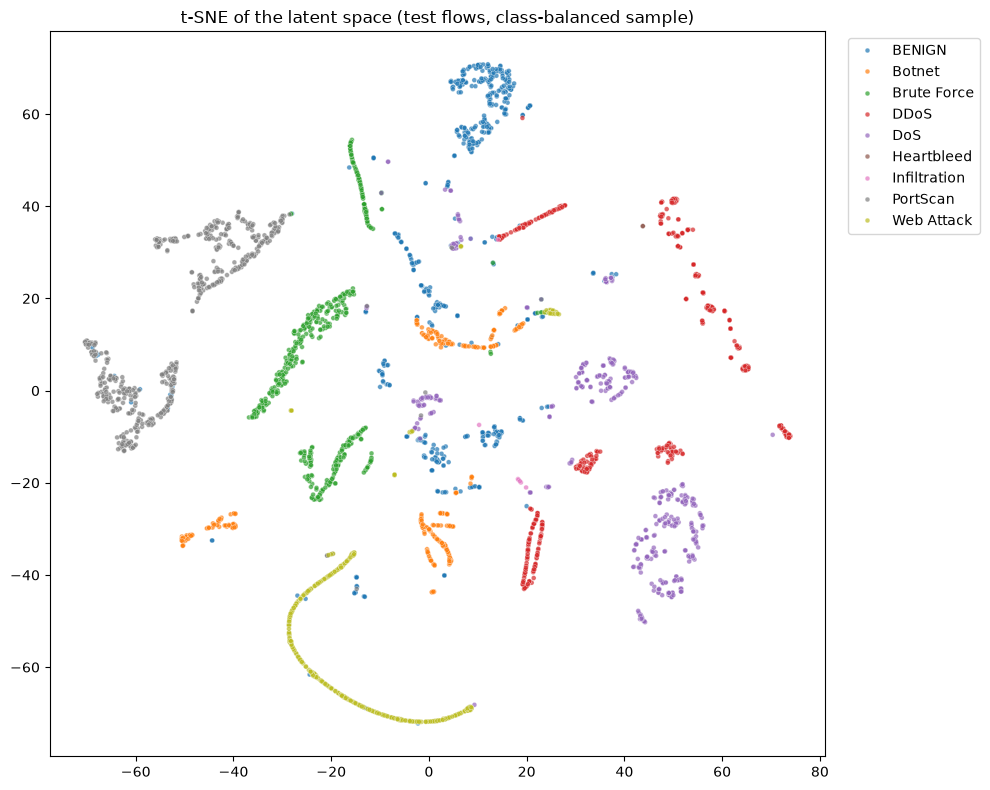

In [25]:
rng = np.random.default_rng(RANDOM_STATE)
sample_index = np.concatenate([
    rng.choice(np.where(y_test == label)[0], size=min(600, (y_test == label).sum()), replace=False)
    for label in all_labels
])

latent_2d = TSNE(n_components=2, perplexity=30, init='pca', random_state=RANDOM_STATE).fit_transform(
    test_latent[sample_index]
)

silhouette_input = silhouette_score(X_test[sample_index], y_test[sample_index])
silhouette_latent = silhouette_score(test_latent[sample_index], y_test[sample_index])
print(f'Silhouette score - raw input: {silhouette_input:.4f}   latent space: {silhouette_latent:.4f}')
all_metrics['silhouette_input'] = float(silhouette_input)
all_metrics['silhouette_latent'] = float(silhouette_latent)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=latent_2d[:, 0], y=latent_2d[:, 1], hue=np.array(class_names)[y_test[sample_index]],
    s=12, alpha=0.7, palette='tab10',
)
plt.title('t-SNE of the latent space (test flows, class-balanced sample)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'latent_tsne.png', dpi=150)
plt.show()

with open(RESULTS_DIR / 'metrics.json', 'w') as file:
    json.dump(all_metrics, file, indent=2)

## Step 26 - Find the most frequently confused classes

In [26]:
confused_pairs = [
    {'true_class': class_names[true], 'predicted_class': class_names[predicted], 'flows': int(matrix[true, predicted]),
     'share_of_true_class': matrix[true, predicted] / matrix[true].sum()}
    for true in all_labels for predicted in all_labels
    if true != predicted and matrix[true, predicted] > 0
]
confused_pairs = pd.DataFrame(confused_pairs).sort_values('flows', ascending=False)
confused_pairs.to_csv(RESULTS_DIR / 'confused_pairs.csv', index=False)
display(confused_pairs.head(10).round(4))

,true_class,predicted_class,flows,share_of_true_class
0,BENIGN,Botnet,11743,0.0280
3,BENIGN,DoS,8277,0.0197
6,BENIGN,PortScan,6797,0.0162
2,BENIGN,DDoS,3782,0.0090
7,BENIGN,Web Attack,3479,0.0083
1,BENIGN,Brute Force,1393,0.0033
18,DoS,Web Attack,283,0.0073
5,BENIGN,Infiltration,203,0.0005
14,DoS,BENIGN,76,0.0020
11,Brute Force,Web Attack,44,0.0240


## Step 27 - Summary for the report

Use the evidence produced above to answer these questions in the critical analysis:

1. **Does denoising help?** Compare the `noise_std = 0.0` row with the noisy rows in `tuning_results.csv`.
2. **Is the latent space useful?** Compare the input and latent silhouette scores, and look at the t-SNE plot.
3. **Does reconstruction optimise what classification needs?** Compare the reconstruction-error ROC-AUC with the supervised ROC-AUC. Look at which attack classes have a *low* reconstruction error: those look "normal" to the autoencoder, and the classifier must rely on the supervised signal to catch them.
4. **Overfitting?** Look at the train / validation / test gap in Step 18 and the learning curves in Step 15.
5. **Minority classes:** Check the recall of Heartbleed, Infiltration, Web Attack and Botnet. The very small test support of the rarest classes makes their scores unstable.
6. **Cost:** Compare the parameter count, training time and inference time with the MLP.

In [27]:
summary = pd.concat([
    pd.Series(multiclass_metrics).add_prefix('multiclass_'),
    pd.Series(binary_metrics).add_prefix('binary_'),
    pd.Series({
        'best_validation_macro_f1': best_val_f1,
        'reconstruction_error_roc_auc': reconstruction_auc,
        'silhouette_input': silhouette_input,
        'silhouette_latent': silhouette_latent,
        'total_parameters': parameter_count,
        'total_training_seconds': pretrain_seconds + finetune_seconds,
        'inference_ms_per_1000_flows': efficiency_metrics['inference_ms_per_1000_flows'],
    }),
])
summary

multiclass_accuracy                  0.928228
multiclass_balanced_accuracy         0.968519
multiclass_macro_precision           0.533633
multiclass_macro_recall              0.968519
multiclass_macro_f1                  0.603441
multiclass_weighted_f1               0.943369
binary_precision                     0.704526
binary_recall_detection_rate         0.998673
binary_f1                            0.826199
binary_roc_auc                       0.995485
binary_pr_auc                        0.979416
binary_false_positive_rate           0.085083
binary_mcc                           0.802109
binary_true_negative            383622.000000
binary_false_positive            35675.000000
binary_false_negative              113.000000
binary_true_positive             85063.000000
best_validation_macro_f1             0.629494
reconstruction_error_roc_auc         0.698467
silhouette_input                     0.096834
silhouette_latent                    0.259138
total_parameters                 4